In [408]:
import pandas as pd
#from sklearn import 
import os
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import geodatasets
import pydeck as pdk
import streamlit as st

<b>First</b> I want to bring in my dataset to start playing with the data

In [374]:
df = pd.read_csv('data-2026-03.csv', names=['siteid', 'direction', 'type', 'start', 'end', 'count'])

sites = pd.read_csv('sites.csv', names=['siteid', 'site_nr', 'longitude', 'latitude', 'name', 'region', 'direction_number', 'district', 'municipality', 'interval', 'date'])

In [3]:
df.head(10)

,siteid,direction,type,start,end,count
0,1,IN,FIETSERS,2026-03-01 00:00:00.0,2026-03-01 00:15:00.0,0.0
1,1,IN,FIETSERS,2026-03-01 00:15:00.0,2026-03-01 00:30:00.0,0.0
2,1,IN,FIETSERS,2026-03-01 00:30:00.0,2026-03-01 00:45:00.0,0.0
3,1,IN,FIETSERS,2026-03-01 00:45:00.0,2026-03-01 01:00:00.0,0.0
4,1,IN,FIETSERS,2026-03-01 01:00:00.0,2026-03-01 01:15:00.0,1.0
5,1,IN,FIETSERS,2026-03-01 01:15:00.0,2026-03-01 01:30:00.0,0.0
6,1,IN,FIETSERS,2026-03-01 01:30:00.0,2026-03-01 01:45:00.0,1.0
7,1,IN,FIETSERS,2026-03-01 01:45:00.0,2026-03-01 02:00:00.0,0.0
8,1,IN,FIETSERS,2026-03-01 02:00:00.0,2026-03-01 02:15:00.0,0.0
9,1,IN,FIETSERS,2026-03-01 02:15:00.0,2026-03-01 02:30:00.0,0.0


Will want to group sites into a smaller classification so they can be clustered. Maybe group by hour by splitting the start and end times into the hours?

In [ ]:
#break the start and end into its component parts
#takes about 4 mins 21 secs to run
df['start_date'] = 'NULL'
df['start_time'] = 0
df['end_date'] = 'NULL'
df['end_time'] = 0




for index, val in df.iterrows():
    df.loc[index, 'start_date'] = df.loc[index, 'start'][:10]
    df.loc[index, 'start_date'] = df.loc[index, 'start_date'][:10]
    
    df.loc[index, 'start_time'] = df.loc[index, 'start'][11:]
    df.loc[index, 'start_time'] = df.loc[index, 'start_time'][:]

    df.loc[index, 'end_date'] = df.loc[index, 'end'][:10]
    df.loc[index, 'end_date'] = df.loc[index, 'end_date'][:10]

    df.loc[index, 'end_time'] = df.loc[index, 'end'][11:]
    df.loc[index, 'end_time'] = df.loc[index, 'end_time'][:]





/var/folders/2v/fznvvjm17tsbhvss80_3zmc00000gn/T/ipykernel_19249/3910747018.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:00:00.0' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[index, 'start_time'] = df.loc[index, 'start'][11:]
/var/folders/2v/fznvvjm17tsbhvss80_3zmc00000gn/T/ipykernel_19249/3910747018.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:15:00.0' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[index, 'end_time'] = df.loc[index, 'end'][11:]


In [33]:
print(df.loc[index, 'end'][11:])
df.head(10)

05:00:00.0


,siteid,direction,type,start,end,count,start_date,start_time,end_date,end_time
0,1,IN,FIETSERS,2026-03-01 00:00:00.0,2026-03-01 00:15:00.0,0.0,2026-03-01,00:00:00.0,2026-03-01,00:15:00.0
1,1,IN,FIETSERS,2026-03-01 00:15:00.0,2026-03-01 00:30:00.0,0.0,2026-03-01,00:15:00.0,2026-03-01,00:30:00.0
2,1,IN,FIETSERS,2026-03-01 00:30:00.0,2026-03-01 00:45:00.0,0.0,2026-03-01,00:30:00.0,2026-03-01,00:45:00.0
3,1,IN,FIETSERS,2026-03-01 00:45:00.0,2026-03-01 01:00:00.0,0.0,2026-03-01,00:45:00.0,2026-03-01,01:00:00.0
4,1,IN,FIETSERS,2026-03-01 01:00:00.0,2026-03-01 01:15:00.0,1.0,2026-03-01,01:00:00.0,2026-03-01,01:15:00.0
5,1,IN,FIETSERS,2026-03-01 01:15:00.0,2026-03-01 01:30:00.0,0.0,2026-03-01,01:15:00.0,2026-03-01,01:30:00.0
6,1,IN,FIETSERS,2026-03-01 01:30:00.0,2026-03-01 01:45:00.0,1.0,2026-03-01,01:30:00.0,2026-03-01,01:45:00.0
7,1,IN,FIETSERS,2026-03-01 01:45:00.0,2026-03-01 02:00:00.0,0.0,2026-03-01,01:45:00.0,2026-03-01,02:00:00.0
8,1,IN,FIETSERS,2026-03-01 02:00:00.0,2026-03-01 02:15:00.0,0.0,2026-03-01,02:00:00.0,2026-03-01,02:15:00.0
9,1,IN,FIETSERS,2026-03-01 02:15:00.0,2026-03-01 02:30:00.0,0.0,2026-03-01,02:15:00.0,2026-03-01,02:30:00.0


Next I want to add some features to better map the space I can work with.

The list of these is below:
1. Is it the weekend? 1 if yes else 0
2. Sum per hour and create a new column called hour with an integer representing the hour
3. Maybe a month specific qualifier? Like is_summer or is_winter?
4. TBD once I continue working I can try and implement something new
5. Direction, 1 in IN 0 else

In [49]:
for index, val in df.iterrows():
    df.loc[index, 'hour'] = pd.to_numeric(df.loc[index, 'start_time'][:2])

In [234]:
#this works
df['hour_count'] = df.groupby(['siteid', 'start_date', 'hour', 'direction'])['count'].cumsum()

In [235]:
df[['siteid', 'start_time', 'hour', 'count', 'hour_count']].head(20)

,siteid,start_time,hour,count,hour_count
0,1,00:00:00.0,0.0,0.0,0.0
1,1,00:15:00.0,0.0,0.0,0.0
2,1,00:30:00.0,0.0,0.0,0.0
3,1,00:45:00.0,0.0,0.0,0.0
4,1,01:00:00.0,1.0,1.0,1.0
5,1,01:15:00.0,1.0,0.0,1.0
6,1,01:30:00.0,1.0,1.0,2.0
7,1,01:45:00.0,1.0,0.0,2.0
8,1,02:00:00.0,2.0,0.0,0.0
9,1,02:15:00.0,2.0,0.0,0.0


In [70]:
for index, val in df.iterrows():
    insert_val = 0
    if df.loc[index, 'direction'] == 'IN':
        insert_val = 1
    df.loc[index, 'direction_binary'] = insert_val

In [75]:
for index, val in df.iterrows():
    insert_val = 0
    if df.loc[index, 'start_date'] == '2026-03-01':
        insert_val = 1
    elif df.loc[index, 'start_date'] == '2026-03-07' or df.loc[index, 'start_date'] == '2026-03-08':
        insert_val = 1
    elif df.loc[index, 'start_date'] == '2026-03-14' or df.loc[index, 'start_date'] == '2026-03-15':
        insert_val = 1
    elif df.loc[index, 'start_date'] == '2026-03-21':
        insert_val = 1
    df.loc[index, 'is_weekend'] = insert_val

In [160]:
for index, val in df.iterrows():
    df.loc[index, 'day'] = pd.to_numeric(df.loc[index, 'start_date'][-2:])

In [236]:
df

,siteid,direction,type,start,end,count,start_date,start_time,end_date,end_time,hour,hour_count,direction_binary,is_weekend,day
0,1,IN,FIETSERS,2026-03-01 00:00:00.0,2026-03-01 00:15:00.0,0.0,2026-03-01,00:00:00.0,2026-03-01,00:15:00.0,0.0,0.0,1.0,1.0,1.0
1,1,IN,FIETSERS,2026-03-01 00:15:00.0,2026-03-01 00:30:00.0,0.0,2026-03-01,00:15:00.0,2026-03-01,00:30:00.0,0.0,0.0,1.0,1.0,1.0
2,1,IN,FIETSERS,2026-03-01 00:30:00.0,2026-03-01 00:45:00.0,0.0,2026-03-01,00:30:00.0,2026-03-01,00:45:00.0,0.0,0.0,1.0,1.0,1.0
3,1,IN,FIETSERS,2026-03-01 00:45:00.0,2026-03-01 01:00:00.0,0.0,2026-03-01,00:45:00.0,2026-03-01,01:00:00.0,0.0,0.0,1.0,1.0,1.0
4,1,IN,FIETSERS,2026-03-01 01:00:00.0,2026-03-01 01:15:00.0,1.0,2026-03-01,01:00:00.0,2026-03-01,01:15:00.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573069,152,OUT,FIETSERS,2026-03-21 03:45:00.0,2026-03-21 04:00:00.0,0.0,2026-03-21,03:45:00.0,2026-03-21,04:00:00.0,3.0,0.0,0.0,1.0,21.0
573070,152,OUT,FIETSERS,2026-03-21 04:00:00.0,2026-03-21 04:15:00.0,0.0,2026-03-21,04:00:00.0,2026-03-21,04:15:00.0,4.0,0.0,0.0,1.0,21.0
573071,152,OUT,FIETSERS,2026-03-21 04:15:00.0,2026-03-21 04:30:00.0,0.0,2026-03-21,04:15:00.0,2026-03-21,04:30:00.0,4.0,0.0,0.0,1.0,21.0
573072,152,OUT,FIETSERS,2026-03-21 04:30:00.0,2026-03-21 04:45:00.0,0.0,2026-03-21,04:30:00.0,2026-03-21,04:45:00.0,4.0,0.0,0.0,1.0,21.0


In [281]:
df1 = df[['siteid', 'hour', 'hour_count', 'is_weekend', 'day', 'direction_binary']]

In [295]:
#df1[df1.isna()]
# Source - https://stackoverflow.com/a/37755016
# Posted by michael_j_ward
# Retrieved 2026-05-20, License - CC BY-SA 3.0

#np.argwhere(np.isnan(df1))


df1.loc[:, ['hour_count']] = df1.loc[:, ['hour_count']].fillna(0)
df1.iloc[256754, 2]

#df1

np.float64(0.0)

In [308]:
df1_crazy = df1.copy()


df1_crazy.replace(0, 10000)

,siteid,hour,hour_count,is_weekend,day,direction_binary
0,1,10000.0,10000.0,1.0,1.0,1.0
1,1,10000.0,10000.0,1.0,1.0,1.0
2,1,10000.0,10000.0,1.0,1.0,1.0
3,1,10000.0,10000.0,1.0,1.0,1.0
4,1,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...
573069,152,3.0,10000.0,1.0,21.0,10000.0
573070,152,4.0,10000.0,1.0,21.0,10000.0
573071,152,4.0,10000.0,1.0,21.0,10000.0
573072,152,4.0,10000.0,1.0,21.0,10000.0


In [355]:
#need to do some group bys to try and get better data
#Min count, min count hour, max count, max count hour, min count direction, max count direction, siteid

temp_df1 = df1.groupby('siteid')['hour_count'].idxmin()
temp_df2 = df1.groupby('siteid')['hour_count'].idxmin()
temp_df3 = df1.groupby('siteid')['hour_count'].idxmin()

temp_df4 = df1.groupby('siteid')['hour_count'].idxmax()
temp_df5 = df1.groupby('siteid')['hour_count'].idxmax()
temp_df6 = df1.groupby('siteid')['hour_count'].idxmax()

temp_df7 = df1.groupby('siteid')['hour_count'].mean()

temp_df_dict = {'min_count': temp_df1,
                'min_count_hour': temp_df2,
                'max_count': temp_df3,
                'max_count_hour': temp_df4,
                'min_count_direction': temp_df5,
                'max_count_direction': temp_df6}


#df1

In [310]:
temp_df1

siteid
1           0
2        3884
3        7758
4       11638
5       15520
        ...  
148    553034
149    557074
150    561114
151    565154
152    569194
Name: hour_count, Length: 145, dtype: int64

In [354]:
pd.to_numeric(df1[df1['siteid']==2].groupby('siteid')['hour_count'].mean())

siteid
2    14.259928
Name: hour_count, dtype: float64

In [358]:
df_cluster = pd.DataFrame()
indx_count = 0
indx_count2 = 0

for indx in temp_df4:
    df_cluster.loc[indx_count, 'siteid'] = int(indx_count + 1)
    df_cluster.loc[indx_count, 'max_hour_count'] = df1.loc[indx, 'hour_count']
    df_cluster.loc[indx_count, 'max_hour'] = df1.loc[indx, 'hour']
    df_cluster.loc[indx_count, 'max_direction'] = df1.loc[indx, 'direction_binary']
    indx_count += 1
    
#include averages
for index in temp_df7:
    df_cluster.loc[indx_count2, 'average_hour_count'] = index
    indx_count2 += 1



In [359]:
df_cluster

,siteid,max_hour_count,max_hour,max_direction,average_hour_count
0,1.0,64.0,10.0,1.0,5.727577
1,2.0,238.0,8.0,1.0,14.259928
2,3.0,203.0,16.0,0.0,12.619588
3,4.0,60.0,11.0,0.0,3.116435
4,5.0,57.0,16.0,0.0,2.935494
...,...,...,...,...,...
140,141.0,88.0,17.0,1.0,6.185149
141,142.0,48.0,8.0,1.0,4.845050
142,143.0,42.0,15.0,0.0,2.061386
143,144.0,30.0,8.0,1.0,2.601733


In [367]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto').fit(df_cluster)

In [368]:
df2 = df_cluster.copy()

In [369]:
df2['cluster'] = kmeans.labels_

In [242]:
df.groupby(['siteid', 'day'])['hour_count'].max()

siteid  day 
1       1.0     64.0
        2.0     41.0
        3.0     47.0
        4.0     44.0
        5.0     36.0
                ... 
152     17.0    54.0
        18.0    52.0
        19.0    50.0
        20.0    44.0
        21.0     2.0
Name: hour_count, Length: 3112, dtype: float64

In [227]:
df21 = df[df['day']==19]

In [228]:
df21_test = df21[df21['siteid']==152]

In [233]:
for index, val in df21_test.iterrows():
    print(val)

siteid                                152
direction                              IN
type                             FIETSERS
start               2026-03-19 00:00:00.0
end                 2026-03-19 00:15:00.0
count                                 0.0
start_date                     2026-03-19
start_time                     00:00:00.0
end_date                       2026-03-19
end_time                       00:15:00.0
hour                                  0.0
hour_count                          262.0
direction_binary                      1.0
is_weekend                            0.0
day                                  19.0
Name: 570922, dtype: object
siteid                                152
direction                              IN
type                             FIETSERS
start               2026-03-19 00:15:00.0
end                 2026-03-19 00:30:00.0
count                                 0.0
start_date                     2026-03-19
start_time                     00:15:00.0
end_da

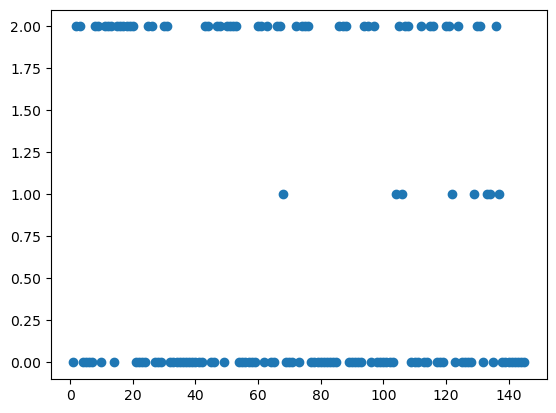

In [370]:
fig, ax = plt.subplots()
ax.scatter(df2['siteid'], df2['cluster'])

#plt.savefig('testing.png', dpi=500)
#df2[['siteid', 'cluster']]

I need a way to group each site so I can then run k-means and get clusters PER SITE not per recorded instance

weights per hour based on count to indicate where the most rides occur

maybe max and min hours or max and min counts? remove direction

Hour with max cyclists per day and then average those

In [371]:
df2.to_csv('testing.csv', index=False)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto').fit(df3)

Now I will want to map the clusters to see if these results make some kind of sense

In [376]:
sites.head(200)

,siteid,site_nr,longitude,latitude,name,region,direction_number,district,municipality,interval,date
0,1,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22
1,2,100052862,4.471690,51.275120,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22
2,3,100052863,4.472220,51.275030,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22
3,4,100052864,5.190110,51.160230,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
4,5,100052865,5.190030,51.160180,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
...,...,...,...,...,...,...,...,...,...,...,...
146,148,300060140,4.444710,50.766995,Hoeilaart,Vlaamse Overheid A. Wegen en Verkeer,N2750002,Hoeilaart,District Leuven,0,2025-08-23
147,149,300060264,4.433566,50.882979,Machelen,Vlaamse Overheid A. Wegen en Verkeer,NaN,NaN,NaN,0,2025-08-28
148,150,300061690,4.561363,50.868753,Bertem,Vlaamse Overheid A. Wegen en Verkeer,A0030002,Kortenberg,District Leuven,15,2025-10-17
149,151,300061739,4.685484,50.869026,Leuven,Vlaamse Overheid A. Wegen en Verkeer,N2640002,Leuven,District Leuven,0,2025-10-18


In [409]:
starting_view = pdk.ViewState(latitude= 5, longitude= 50, zoom= 10, max_zoom= 16)

site_locations = pdk.Layer(
    'ScatterplotLayer',
    sites[['longitude', 'latitude']],
    auto_highlight=True,
    get_position=['longitude', 'latitude'],
    get_radius=1000,
    get_fill_color=[100,100,200,0],
    pickable=True
)

design = pdk.Deck(layers= [site_locations], initial_view_state = starting_view)
st.pydeck_chart(design)

2026-05-21 17:25:39.323 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 17:25:39.325 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 17:25:39.376 
  command:

    streamlit run /opt/anaconda3/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-05-21 17:25:39.376 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [402]:
sites[['longitude', 'latitude']]

,longitude,latitude
0,4.456122,50.916183
1,4.471690,51.275120
2,4.472220,51.275030
3,5.190110,51.160230
4,5.190030,51.160180
...,...,...
146,4.444710,50.766995
147,4.433566,50.882979
148,4.561363,50.868753
149,4.685484,50.869026
